<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-4-projekt-grupowy-2/blob/main/1_Analiza_Przygotowanie_Danych.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Zbiór:** Stroke Prediction Dataset

**Główny problem:** Klasyfikacja zawałów serca u pacjentów (1 - zawał, 0 - brak zawału)

**Wczytanie bibliotek**

In [18]:
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Wczytanie i opis danych**

In [19]:
data = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")

print(30*"-", "Opis kolumn", 30*"-")
data.info()
print("\n")

print(30*"-", "Statystyki kolumn numerycznych", 30*"-")
display(data.describe().round(2))
print("\n")

print(30*"-", "Brakujące dane", 30*"-")
display(data.isnull().sum())

------------------------------ Opis kolumn ------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


------------------------------ Statystyki kolumn numerycznych -------------------

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00




------------------------------ Brakujące dane ------------------------------


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


Mamy 12 kolumn, w jednej [bmi] brakuje danych, będzie trzeba je uzupełnić

**Rozkład danych w zbiorze**

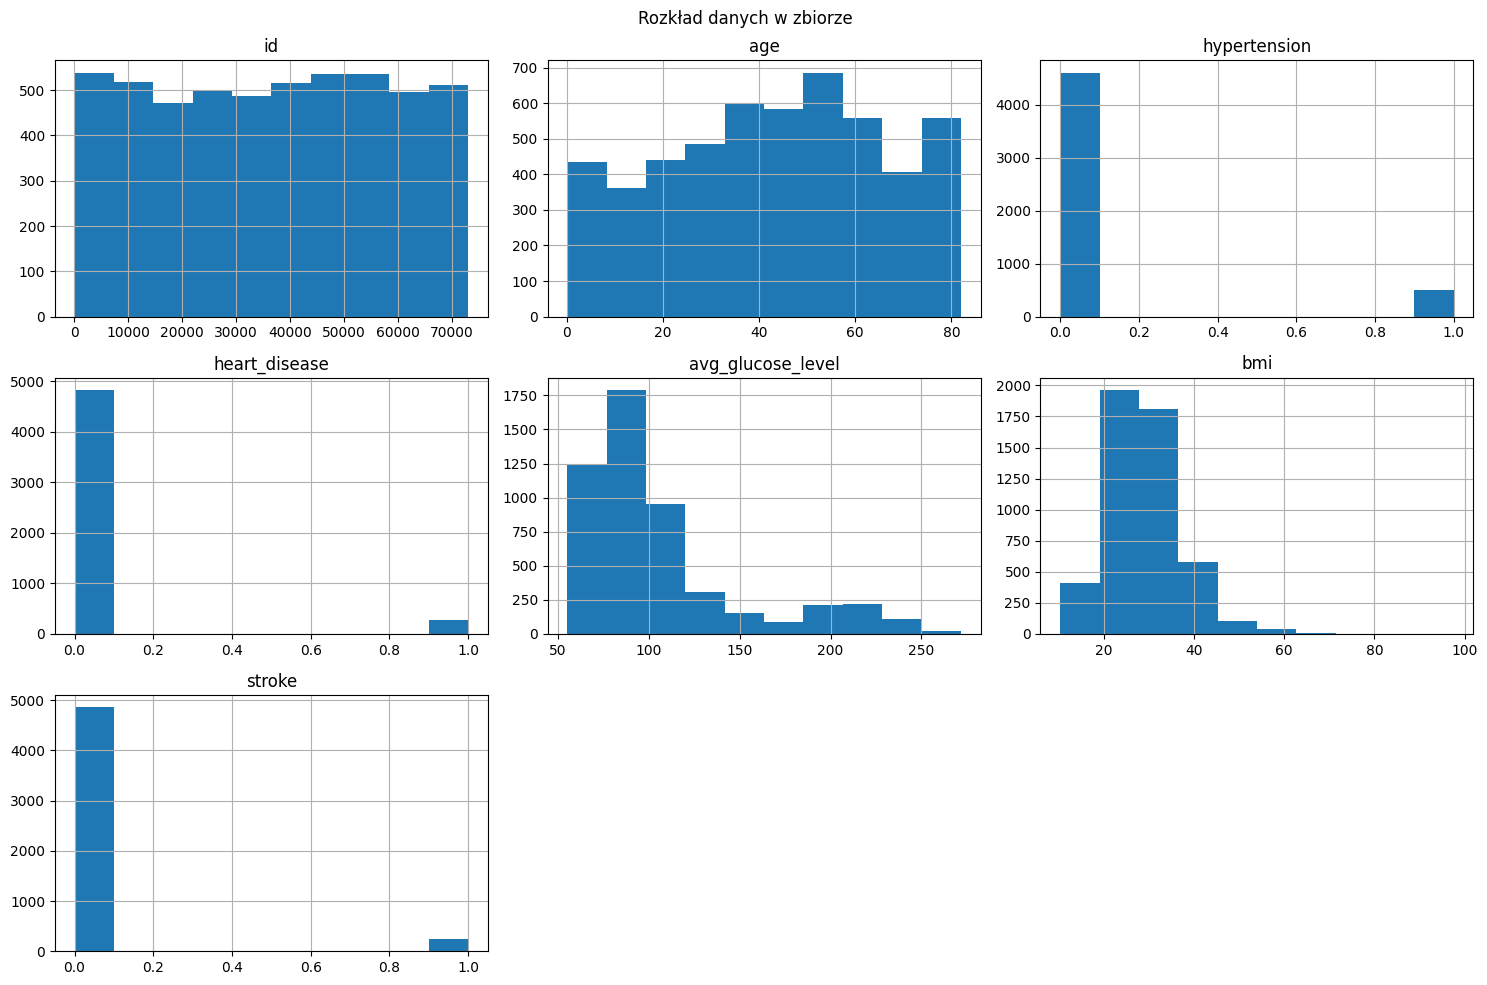

In [20]:
data.hist(figsize=(15, 10))
plt.suptitle("Rozkład danych w zbiorze")
plt.tight_layout()

**Sprawdzenie zbilansowania klas**

stroke
0    4861
1     249
Name: count, dtype: int64


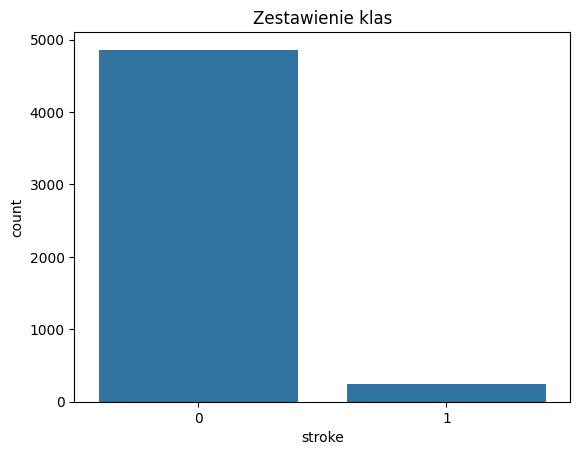

In [21]:
print(data['stroke'].value_counts())

sns.countplot(x=data['stroke'])
plt.title("Zestawienie klas")
plt.show()

Widać, że mamy bardzo niezbilansowane klasy. Czyli metryka accuracy będzie bezużyteczna.

**Poszukiwanie outlierów**

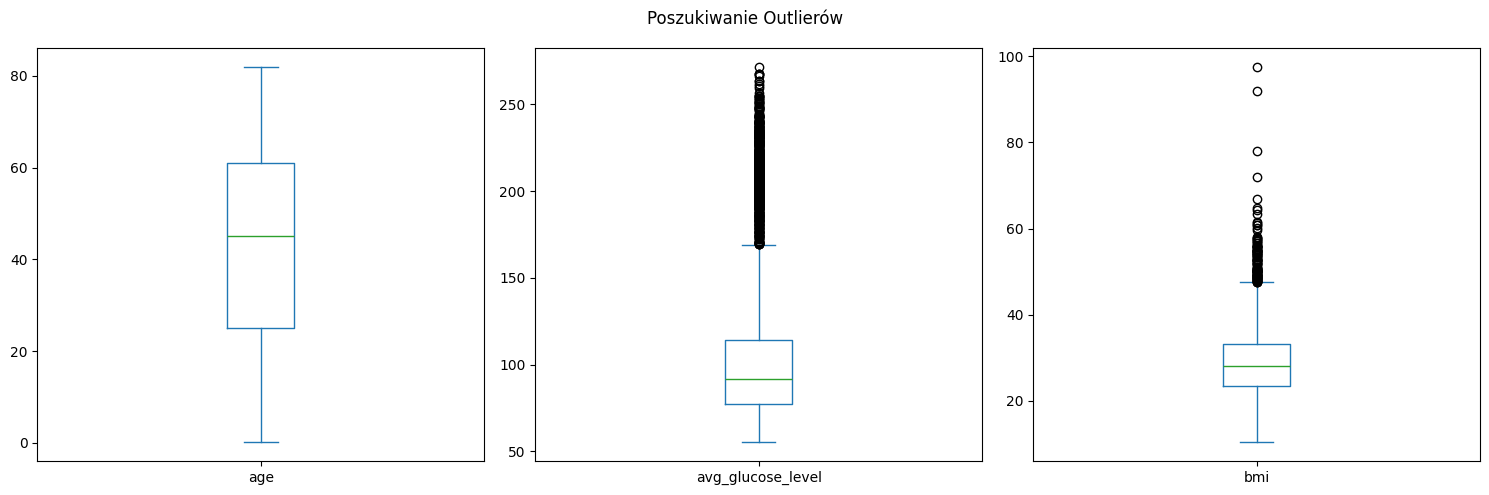

In [22]:
cols = ["age", "avg_glucose_level", "bmi"]

data[cols].plot(kind='box', subplots=True, layout=(1, 3), figsize=(15, 5), title="Poszukiwanie Outlierów")
plt.tight_layout()
plt.show()

Mamy dużo outlierów w avg_glucose_level i bmi, nie powinniśmy ich usuwać ponieważ są to dane wpływające na szansę zawału (np. zaawansowana cukrzyca)

**Macierz korelacji**

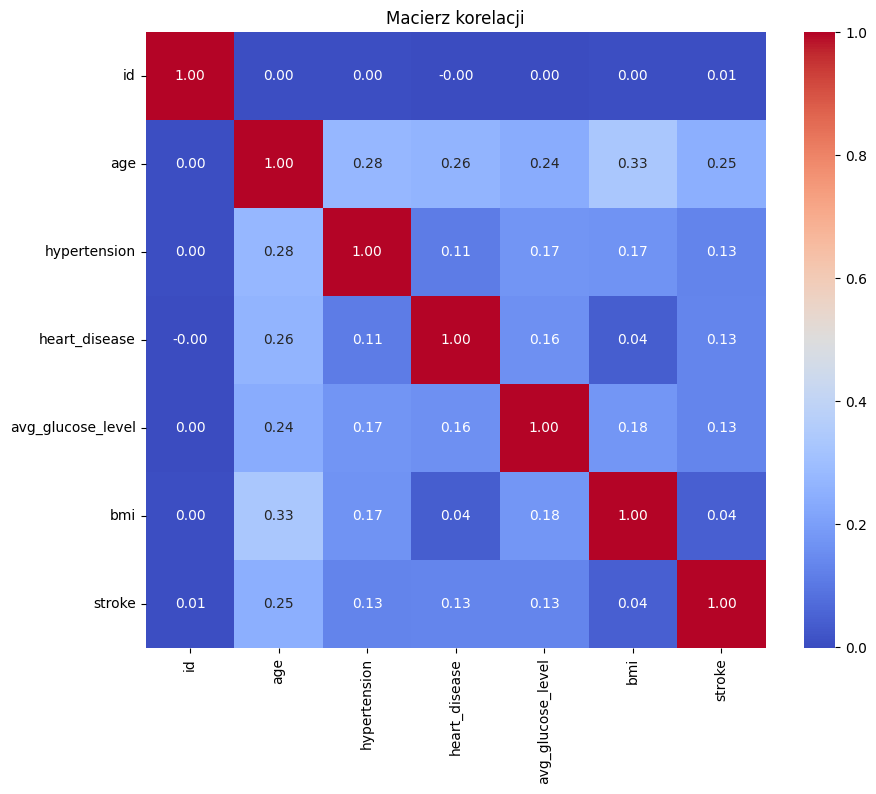

In [23]:
plt.figure(figsize=(10, 8))

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Macierz korelacji")

plt.show()

Widać korelacje pomiędzy wiekiem, a zawałem serca. Ogólnie, im wyższy wiek, tym więcej dolegliwości u danej osoby widać w danych.

Widać też, że nasza kolumna [bmi] z brakującymi wartościami ma silne powiązanie z wiekiem.

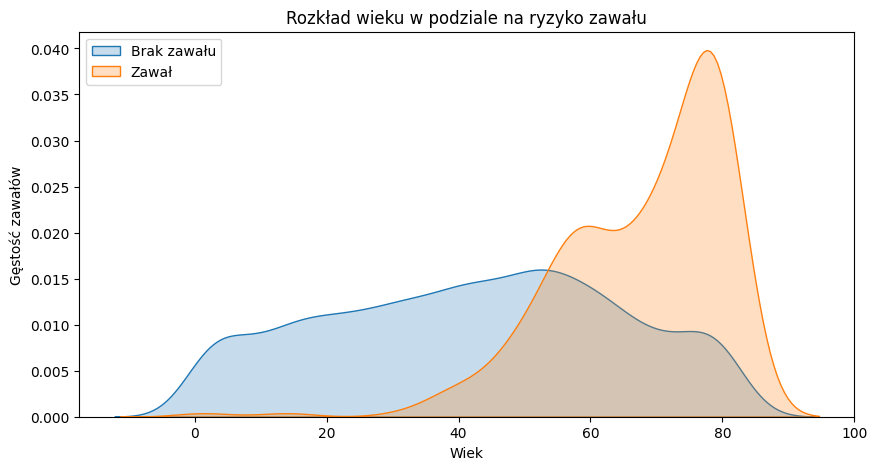

In [24]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data[data['stroke'] == 0], x="age", label="Brak zawału", fill=True)
sns.kdeplot(data=data[data['stroke'] == 1], x="age", label="Zawał", fill=True)

plt.title("Rozkład wieku w podziale na ryzyko zawału")
plt.xlabel("Wiek")
plt.ylabel("Gęstość zawałów")
plt.legend()
plt.show()

**Preprocessing danych**

**Selekcja cech - usunięcie kolumny id**

In [25]:
data = data.drop("id", axis=1)

**One-hot encoding (przekształcenie danych w całkowicie numeryczne)**

In [26]:
data = pd.get_dummies(data, drop_first=True, dtype=int)

**Podział na zbiór testowy i treningowy**

In [27]:
X = data.drop("stroke", axis=1)
y = data["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Uzupełnienie brakujących wartości (w kolumnie bmi)**

In [28]:
medians_by_age = X_train.groupby('age')['bmi'].median()

global_median = X_train['bmi'].median()

def fill_bmi(row):
    if pd.isna(row['bmi']):
        return medians_by_age.get(row['age'], global_median)
    return row['bmi']

X_train['bmi'] = X_train.apply(fill_bmi, axis=1)
X_test['bmi'] = X_test.apply(fill_bmi, axis=1)

print("Braki w X_train po uzupełnieniu:\n", X_train.isnull().sum())
print("Braki w X_test po uzupełnieniu:\n", X_test.isnull().sum())

Braki w X_train po uzupełnieniu:
 age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64
Braki w X_test po uzupełnieniu:
 age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private   

**Standaryzacja danych**

In [29]:
scaler = StandardScaler()
true_num_cols = ["age", "avg_glucose_level", "bmi"]

X_train[true_num_cols] = scaler.fit_transform(X_train[true_num_cols])
X_test[true_num_cols] = scaler.transform(X_test[true_num_cols])

**Eksport danych do plików CSV**

In [30]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)